## Data 102 Final Project

Group 16: Evelyn Shen, Stephanie Yew, Yixiao Yang, Anna Su

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
import datetime

from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.feature_extraction import DictVectorizer

from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

from sklearn import preprocessing

from sklearn.model_selection import KFold
from sklearn.preprocessing import normalize
from sklearn.linear_model import LogisticRegression
from sklearn import tree
from sklearn import ensemble

In [3]:
%pip install -U scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 44.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


## Research Questions

 1) Can we predict CO2 emissions from power plants from NERC grid regions based on nonrenewable and renewable energy generation and other features? (GLM)

2) After controlling for generation mix (shares of coal, gas, nuclear, and renewables), as well as net energy generation, how much residual variation in power plant CO₂ emission rates can be attributed to other differences in NERC regions? (Bayesian Hierarchical Model)

## Data

We are using the dataset in 2023 from EPA eGrid provided by United States Environmental Protection Agency. This dataset includes nonrenewable and renewable energy generation data by plants, as well as data pertaining to net generation & the ozone layer of each state. We are using two subsections of the same dataset, and combining the demographic dataframe with the plants dataframe.

Renewable energy sources = nuclear, hydro, biomass, wind, solar, geothermal. Nonrenewable energy sources = oil, gas, other fossil generation. We will ignore the other unknown/purchased fuel generation (resource mix) column.

In [5]:
plantdf = pd.read_csv('plantdata.csv')

/tmp/ipykernel_115/2279155834.py:1: DtypeWarning: Columns (0,1,4,6,8,16,17,19,20,22,23,27,29,33,34,35,50,51,52,53,55,56,58,59,60,61,62,63,64,65,66,67,68,69,71,72,74,82,85,86,97,98,99,102,107,122) have mixed types. Specify dtype option on import or set low_memory=False.
  plantdf = pd.read_csv('plantdata.csv')


In [6]:
plantdf.head()

,Plant file sequence number,Data Year,Plant state abbreviation,Plant name,DOE/EIA ORIS plant or facility code,Plant transmission or distribution system owner name,Plant transmission or distribution system owner ID,Utility name,Utility ID,Plant-level sector,...,Plant geothermal generation percent (resource mix),Plant other fossil generation percent (resource mix),Plant other unknown / purchased fuel generation percent (resource mix),Plant total nonrenewables generation percent (resource mix),Plant total renewables generation percent (resource mix),Plant total nonrenewables other unknown/purchased generation percent (resource mix),Plant total nonhydro renewables generation percent (resource mix),Plant total combustion generation percent (resource mix),Plant total noncombustion generation percent (resource mix),Plant total noncombustion other unknown/purchased generation percent (resource mix)
0,SEQPLT23,YEAR,PSTATABB,PNAME,ORISPL,OPRNAME,OPRCODE,UTLSRVNM,UTLSRVID,SECTOR,...,PLGTPR,PLOFPR,PLOPPR,PLTNPR,PLTRPR,PLTOPR,PLTHPR,PLCYPR,PLCNPR,PLCOPR
1,1,2023,AK,Alakanuk,57053,"Alaska Village Elec Coop, Inc",221,"Alaska Village Elec Coop, Inc",221,Electric Utility,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2023,AK,Allison Creek Hydro,58982,"Copper Valley Elec Assn, Inc",4329,"Copper Valley Elec Assn, Inc",4329,Electric Utility,...,0.0%,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%,0.0%,100.0%,0.0%
3,3,2023,AK,Ambler,60243,"Alaska Village Elec Coop, Inc",221,"Alaska Village Elec Coop, Inc",221,Electric Utility,...,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%
4,4,2023,AK,Angoon,7462,"Inside Passage Elec Coop, Inc",18963,"Inside Passage Elec Coop, Inc",18963,Electric Utility,...,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%


Add "Total Population" column from demographic data frame to plant data frame

In [7]:
demodf = pd.read_csv('demographicdata.csv')

/tmp/ipykernel_115/3610491462.py:1: DtypeWarning: Columns (0,1,4,5,6,9,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64) have mixed types. Specify dtype option on import or set low_memory=False.
  demodf = pd.read_csv('demographicdata.csv')


In [8]:
popdf = demodf[["Plant file sequence number"]]

plant_df = pd.merge(plantdf, popdf, on="Plant file sequence number")

In [9]:
plant_df.head()

,Plant file sequence number,Data Year,Plant state abbreviation,Plant name,DOE/EIA ORIS plant or facility code,Plant transmission or distribution system owner name,Plant transmission or distribution system owner ID,Utility name,Utility ID,Plant-level sector,...,Plant geothermal generation percent (resource mix),Plant other fossil generation percent (resource mix),Plant other unknown / purchased fuel generation percent (resource mix),Plant total nonrenewables generation percent (resource mix),Plant total renewables generation percent (resource mix),Plant total nonrenewables other unknown/purchased generation percent (resource mix),Plant total nonhydro renewables generation percent (resource mix),Plant total combustion generation percent (resource mix),Plant total noncombustion generation percent (resource mix),Plant total noncombustion other unknown/purchased generation percent (resource mix)
0,1,2023,AK,Alakanuk,57053,"Alaska Village Elec Coop, Inc",221,"Alaska Village Elec Coop, Inc",221,Electric Utility,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2023,AK,Allison Creek Hydro,58982,"Copper Valley Elec Assn, Inc",4329,"Copper Valley Elec Assn, Inc",4329,Electric Utility,...,0.0%,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%,0.0%,100.0%,0.0%
2,3,2023,AK,Ambler,60243,"Alaska Village Elec Coop, Inc",221,"Alaska Village Elec Coop, Inc",221,Electric Utility,...,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%
3,4,2023,AK,Angoon,7462,"Inside Passage Elec Coop, Inc",18963,"Inside Passage Elec Coop, Inc",18963,Electric Utility,...,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%
4,5,2023,AK,Aniak,7182,Aniak Light & Power Co Inc,4959,Aniak Light & Power Co Inc,4959,Electric Utility,...,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%


### Data Cleaning 

In [10]:
columns_to_keep = [
    # ID
    "Plant file sequence number",

    # Outcome (CO2 intensity)
    "Plant annual CO2 total output emission rate (lb/MWh)",

    # Total CO2 mass
    "Plant annual CO2 emissions (tons)",
    
    # Fuel mix (percentages)
    "Plant coal generation percent (resource mix)",
    "Plant gas generation percent (resource mix)",
    "Plant nuclear generation percent (resource mix)",
    "Plant hydro generation percent (resource mix)",
    "Plant biomass generation percent (resource mix)",
    "Plant wind generation percent (resource mix)",
    "Plant solar generation percent (resource mix)",
    "Plant geothermal generation percent (resource mix)",

    # Primary fuel info (for categorical EDA)
    "Plant primary fuel",
    "Plant primary fuel category",

    # Controls / scale                  
    "Plant annual net generation (MWh)",
    "Plant nameplate capacity (MW)",

    # Location / region
    "Plant state abbreviation",
    "NERC region acronym",
    "eGRID subregion acronym"
]


df = plant_df[columns_to_keep]

In [11]:
df.head(10)

,Plant file sequence number,Plant annual CO2 total output emission rate (lb/MWh),Plant annual CO2 emissions (tons),Plant coal generation percent (resource mix),Plant gas generation percent (resource mix),Plant nuclear generation percent (resource mix),Plant hydro generation percent (resource mix),Plant biomass generation percent (resource mix),Plant wind generation percent (resource mix),Plant solar generation percent (resource mix),Plant geothermal generation percent (resource mix),Plant primary fuel,Plant primary fuel category,Plant annual net generation (MWh),Plant nameplate capacity (MW),Plant state abbreviation,NERC region acronym,eGRID subregion acronym
0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DFO,OIL,0,0.8,AK,AK,AKMS
1,2,NaN,NaN,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%,0.0%,0.0%,WAT,HYDRO,"20,961",6.5,AK,AK,AKMS
2,3,"1,816.360","1,125",0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,DFO,OIL,"1,239",1.1,AK,AK,AKMS
3,4,"2,105.430","1,912",0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,DFO,OIL,"1,816",1.5,AK,AK,AKMS
4,5,"2,121.616","2,140",0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,DFO,OIL,"2,017",1.7,AK,AK,AKMS
5,6,NaN,NaN,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%,0.0%,0.0%,WAT,HYDRO,"8,383",4.0,AK,AK,AKMS
6,7,NaN,387,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DFO,OIL,(236),36.2,AK,AK,AKMS
7,8,"1,922.259","137,788",100.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,SUB,COAL,"143,360",27.5,AK,AK,AKGD
8,9,"1,937.322","45,200",0.0%,100.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,NG,GAS,"46,662",17.3,AK,AK,AKMS
9,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MWH,OTHF,"(2,443)",40.0,AK,AK,AKGD


In [12]:
df.columns

Index(['Plant file sequence number',
       'Plant annual CO2 total output emission rate (lb/MWh)',
       'Plant annual CO2 emissions (tons)',
       'Plant coal generation percent (resource mix)',
       'Plant gas generation percent (resource mix)',
       'Plant nuclear generation percent (resource mix)',
       'Plant hydro generation percent (resource mix)',
       'Plant biomass generation percent (resource mix)',
       'Plant wind generation percent (resource mix)',
       'Plant solar generation percent (resource mix)',
       'Plant geothermal generation percent (resource mix)',
       'Plant primary fuel', 'Plant primary fuel category',
       'Plant annual net generation (MWh)', 'Plant nameplate capacity (MW)',
       'Plant state abbreviation', 'NERC region acronym',
       'eGRID subregion acronym'],
      dtype='object')

In [13]:
df.isna().sum().sort_values(ascending=False)

Plant annual CO2 total output emission rate (lb/MWh)    6100
Plant annual CO2 emissions (tons)                       6032
Plant geothermal generation percent (resource mix)       814
Plant coal generation percent (resource mix)             814
Plant gas generation percent (resource mix)              814
Plant nuclear generation percent (resource mix)          814
Plant hydro generation percent (resource mix)            814
Plant biomass generation percent (resource mix)          814
Plant wind generation percent (resource mix)             814
Plant solar generation percent (resource mix)            814
Plant annual net generation (MWh)                        310
Plant nameplate capacity (MW)                              1
Plant file sequence number                                 0
Plant primary fuel                                         0
Plant primary fuel category                                0
Plant state abbreviation                                   0
NERC region acronym     

In [14]:
num_cols = [
    "Plant annual CO2 total output emission rate (lb/MWh)",
    "Plant annual CO2 emissions (tons)",
    "Plant annual net generation (MWh)",
    "Plant nameplate capacity (MW)",
]

df = df.copy()

df.loc[:, num_cols] = df.loc[:, num_cols].astype(str)

df.loc[:, num_cols] = df.loc[:, num_cols].replace({
    ",": "",            # remove commas
    r"\(": "-",         # convert (236) → -236
    r"\)": "",          # remove closing parenthesis
    r"[^\d\.-]": ""     # remove any leftover non-numeric characters
}, regex=True)

df.loc[:, num_cols] = df.loc[:, num_cols].apply(pd.to_numeric, errors="coerce")

percent_cols = [
    "Plant coal generation percent (resource mix)",
    "Plant gas generation percent (resource mix)",
    "Plant nuclear generation percent (resource mix)",
    "Plant hydro generation percent (resource mix)",
    "Plant biomass generation percent (resource mix)",
    "Plant wind generation percent (resource mix)",
    "Plant solar generation percent (resource mix)",
    "Plant geothermal generation percent (resource mix)"
]

# Clean and convert
df.loc[:, percent_cols] = (
    df.loc[:, percent_cols]
        .astype(str)
        .apply(lambda col: col.str.replace("%", "", regex=False))  # apply .str to each column
        .replace(["--", "", "nan"], np.nan)
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0.0)
)

In [15]:
df = df[df["Plant annual net generation (MWh)"] > 0]

In [16]:
df = df.dropna(subset=["Plant annual CO2 total output emission rate (lb/MWh)"])

In [17]:
df.head(10)

,Plant file sequence number,Plant annual CO2 total output emission rate (lb/MWh),Plant annual CO2 emissions (tons),Plant coal generation percent (resource mix),Plant gas generation percent (resource mix),Plant nuclear generation percent (resource mix),Plant hydro generation percent (resource mix),Plant biomass generation percent (resource mix),Plant wind generation percent (resource mix),Plant solar generation percent (resource mix),Plant geothermal generation percent (resource mix),Plant primary fuel,Plant primary fuel category,Plant annual net generation (MWh),Plant nameplate capacity (MW),Plant state abbreviation,NERC region acronym,eGRID subregion acronym
2,3,1816.36,1125.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DFO,OIL,1239.0,1.1,AK,AK,AKMS
3,4,2105.43,1912.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DFO,OIL,1816.0,1.5,AK,AK,AKMS
4,5,2121.616,2140.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DFO,OIL,2017.0,1.7,AK,AK,AKMS
7,8,1922.259,137788.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,SUB,COAL,143360.0,27.5,AK,AK,AKGD
8,9,1937.322,45200.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,NG,GAS,46662.0,17.3,AK,AK,AKMS
11,12,24119.84,6331.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,NG,GAS,525.0,312.4,AK,AK,AKGD
13,14,1516.957,33324.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DFO,OIL,43935.0,12.6,AK,AK,AKMS
17,18,1588.561,1074.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DFO,OIL,1352.0,1.0,AK,AK,AKMS
18,19,3317.3,469.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DFO,OIL,283.0,1.8,AK,AK,AKMS
20,21,1185.392,1834.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DFO,OIL,3095.0,1.8,AK,AK,AKMS


In [18]:
print(df.shape)

(2407, 18)


During preprocessing we dropped rows with missing values (e.g., missing CO₂ emission rate or net outcome). As a result, some plants were removed entirely. Although some observations were dropped due to missing values, the remaining data still contain enough instances with variation across regions and fuel categories to reveal meaningful patterns. This data can still help us explore the relationships between plant fuel type, population, generation volume, and average CO₂ emission rates, as long as we interpret the results with the missing-data limitation in mind.

## Exploratory Data Analysis

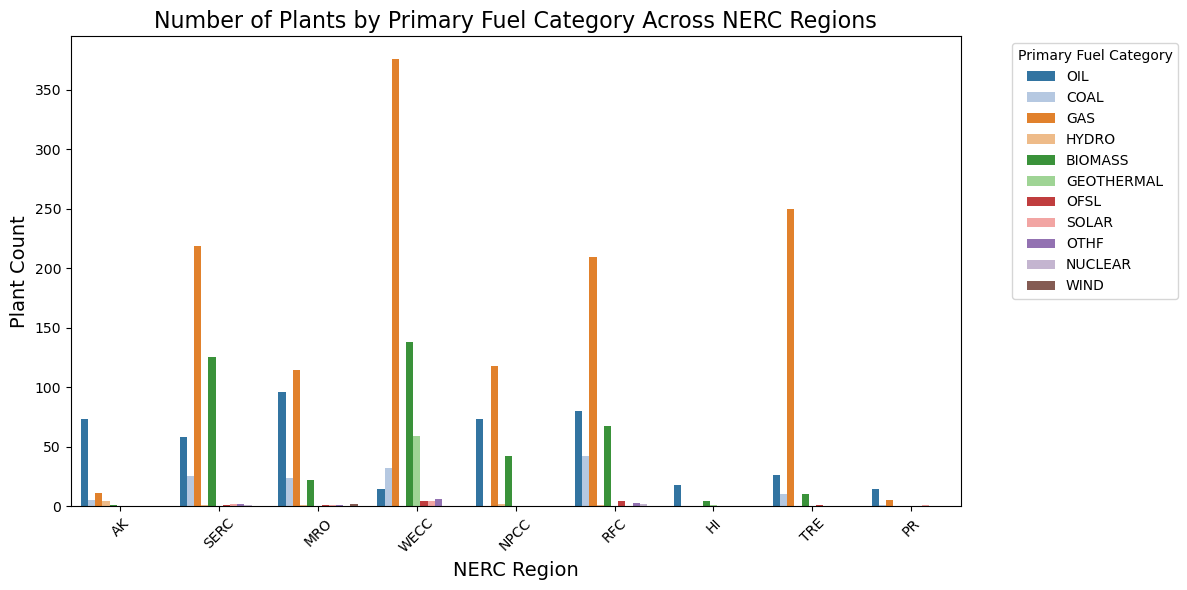

In [19]:
#Categorical Visualization #1
#Number of Plants by Primary Fuel Category Across NERC Regions

plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="NERC region acronym",
    hue="Plant primary fuel category",
    palette="tab20"
)

plt.title("Number of Plants by Primary Fuel Category Across NERC Regions", fontsize=16)
plt.xlabel("NERC Region", fontsize=14)
plt.ylabel("Plant Count", fontsize=14)
plt.xticks(rotation=45)
plt.legend(title="Primary Fuel Category", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

- Gas is the dominant primary fuel category in every major NERC region (SERC, MRO, WECC, NPCC, RFC, and TRE).

- Coal and oil also make up a substantial fraction of plants across all regions.

- Biomass accounts for a surprisingly large number of plants in several regions, especially SERC and WECC, although these units are typically smaller.

- Fuel-type composition varies considerably across NERC regions, indicating structural differences in how electricity is produced.

- Another dimension we could explore is plant size (generation output), since some regions rely on many small plants and others rely on fewer large unit. Differences that may affect regional emission rate patterns.

Because fuel mix strongly influences CO₂ emission rates, these regional differences directly impact our research question. This visualization motivates our Bayesian hierarchical model by showing that regions differ systematically in their generation portfolios, and we want to quantify how much regional variation in CO₂ emission rates remains after adjusting for these differences

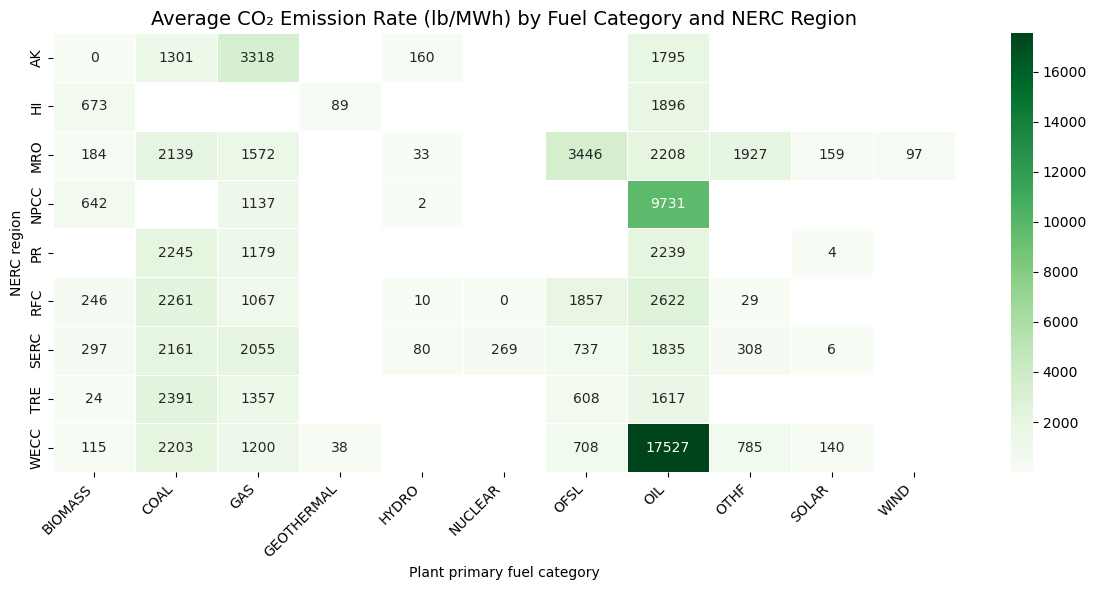

In [20]:
#Categorical Visualization #2
#Heatmap of average CO2 emission rate by fuel category and NERC Region

co2_col = "Plant annual CO2 total output emission rate (lb/MWh)"
df[co2_col] = pd.to_numeric(df[co2_col], errors="coerce")  

grouped = (
    df
    .groupby(["NERC region acronym", "Plant primary fuel category"], as_index=False)
    .agg({co2_col: "mean"})
)

heatmat = grouped.pivot(
    index="NERC region acronym",
    columns="Plant primary fuel category",
    values=co2_col
)

heatmat = heatmat.astype(float)  

plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmat,
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    cmap="Greens" 
)

plt.title("Average CO₂ Emission Rate (lb/MWh) by Fuel Category and NERC Region", fontsize=14)
plt.xlabel("Plant primary fuel category")
plt.ylabel("NERC region")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

From the heat map above, it's clear that there exists differences in average CO₂ emission rates across fuel categories. 

- Oil has the darkest cells, with extremely high emission rates in regions like WECC and NPCC.

- Coal is consistently high across most NERC regions (around 2,000–2,400 lb/MWh), while gas tends to be somewhat lower (roughly 1,000–1,600 lb/MWh).

- Hydro, nuclear, solar, and wind have very light shading and small numeric values, reflecting very low CO₂ emission rates. Biomass is also relatively low compared to fossil fuels.

- Some region–fuel cells in the heat map are blank. They indicate that there are no observations for that region–fuel combination in the cleaned dataset. This is due to how some regions do not have instances of certain plant types. 

This visualization suggests that fuel category is a dominant driver of emission rates: fossil fuels (especially oil and coal) are far more carbon-intensive than renewables and nuclear. That motivates including detailed fuel-mix variables in our model. Also this heat map demonstrates that there is regional difference conditioned on the fuel category. For instance, oil plants in WECC and NPCC have much higher average CO₂ rates than most other cells, even compared to other fossil fuels. This supports the idea of including region indicators to capture residual variation that fuel type alone can’t explain.

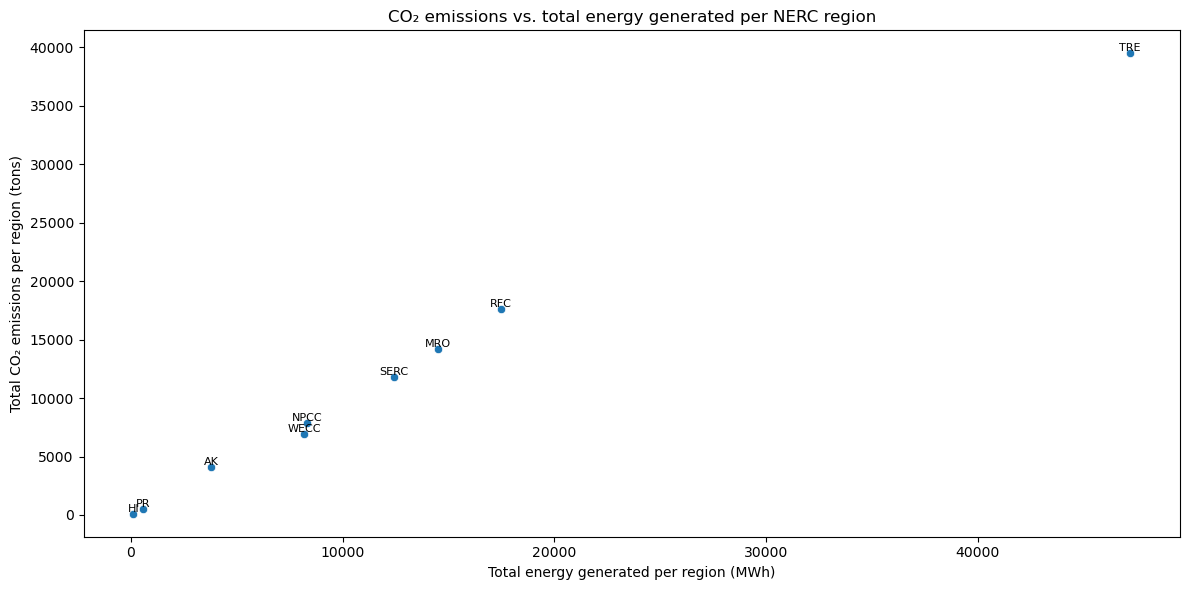

In [21]:
#Quantitative Visualization #1
#Scatter plot of CO2 emissions vs total energy generated per NERC region

num_cols = ["Plant annual CO2 emissions (tons)",
            "Plant annual net generation (MWh)"]

for col in num_cols:
    plant_df[col] = pd.to_numeric(plant_df[col], errors="coerce")

plant_df_clean = plant_df[
    (plant_df["Plant annual CO2 emissions (tons)"] > 0) &
    (plant_df["Plant annual net generation (MWh)"] > 0)
]

region_df = (
    plant_df_clean
    .groupby("NERC region acronym")
    .agg(
        total_co2=("Plant annual CO2 emissions (tons)", "sum"),
        total_gen=("Plant annual net generation (MWh)", "sum"),
    )
    .reset_index()
)

plt.figure(figsize=(12, 6))
ax = sns.scatterplot(
    data=region_df,
    x="total_gen",
    y="total_co2"
)

for _, row in region_df.iterrows():
    ax.text(
        row["total_gen"],
        row["total_co2"],
        row["NERC region acronym"],
        fontsize=8,
        ha="center",
        va="bottom"
    )

ax.set_xlabel("Total energy generated per region (MWh)")
ax.set_ylabel("Total CO₂ emissions per region (tons)")
ax.set_title("CO₂ emissions vs. total energy generated per NERC region")

plt.tight_layout()
plt.show()

The scatterplot shows a clear positive relationship between total energy generated and total CO₂ emissions across NERC regions. Regions that generate more electricity, such as TRE and RFC, also tend to have much higher emissions, while regions with lower total generation have correspondingly lower CO₂ totals. However, the points do not lie perfectly on a straight line: some regions with similar levels of generation have noticeably different emissions, suggesting that differences in fuel mix, plant technology, or efficiency affect the carbon intensity of generation. TRE appears as a high-emission outlier relative to its peers, which motivates a closer look at its generation portfolio.

This visualization directly relates to our first research question: Can we predict CO₂ emissions for select regions based on features such as nonrenewable and renewable energy generation? The apparent positive association between total generation and CO₂ emissions shows that generation volume is a significant predictor, but the wide spread across regions indicates that fuel mix features (coal %, gas %, nuclear %, renewables %) are required to improve prediction accuracy meaningfully.

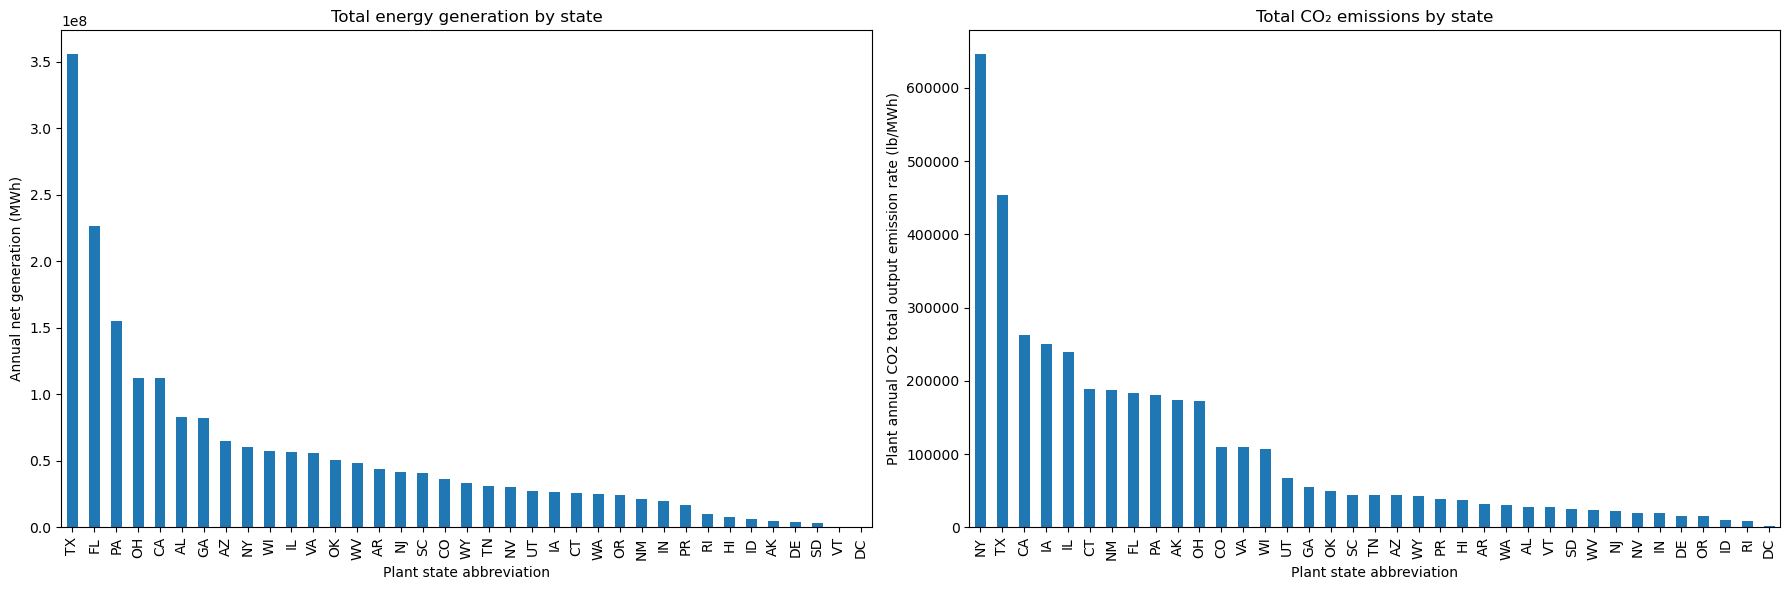

In [22]:
#Quantitative Visualization #2
co2_col = "Plant annual CO2 total output emission rate (lb/MWh)"
gen_col = "Plant annual net generation (MWh)"
state_col = "Plant state abbreviation"

# Compute totals by state
gen_by_state = (
    df.dropna(subset=[state_col, gen_col])
      .groupby(state_col)[gen_col]
      .sum()
      .sort_values(ascending=False)
)

co2_by_state = (
    df.dropna(subset=[state_col, co2_col])
      .groupby(state_col)[co2_col]
      .sum()
      .sort_values(ascending=False)
)

# Side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Net generation plot
gen_by_state.plot(kind="bar", ax=axes[0])
axes[0].set_ylabel("Annual net generation (MWh)")
axes[0].set_title("Total energy generation by state")
axes[0].tick_params(axis='x', rotation=90)

# CO2 emissions plot
co2_by_state.plot(kind="bar", ax=axes[1])
axes[1].set_ylabel("Plant annual CO2 total output emission rate (lb/MWh)")
axes[1].set_title("Total CO₂ emissions by state")
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


In [23]:
df[[co2_col, gen_col]].dtypes

Plant annual CO2 total output emission rate (lb/MWh)    float64
Plant annual net generation (MWh)                        object
dtype: object

In [24]:
#checking how much rows is dropped from only using positive values in the dataframe
df1 = df.copy()
total = len(df1)

# CO2 > 0
mask_co2 = df1[co2_col].notna() & (df1[co2_col] > 0)
kept_co2 = mask_co2.sum()
dropped_co2 = total - kept_co2
print("CO2 > 0:")
print("  kept:", kept_co2)
print("  dropped:", dropped_co2, f"({dropped_co2 / total * 100:.1f}%)")

# Generation > 0
mask_gen = df1[gen_col].notna() & (df1[gen_col] > 0)
kept_gen = mask_gen.sum()
dropped_gen = total - kept_gen
print("\nGeneration > 0:")
print("  kept:", kept_gen)
print("  dropped:", dropped_gen, f"({dropped_gen / total * 100:.1f}%)")


CO2 > 0:
  kept: 2085
  dropped: 322 (13.4%)

Generation > 0:
  kept: 2407
  dropped: 0 (0.0%)


In [25]:
#data cleaning and turning the numbers to numeric values
df1 = df.copy()
def clean_numeric(series):
    s = (
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("(", "-", regex=False)
        .str.replace(")", "", regex=False)
        .replace({"nan": np.nan, "": np.nan})
    )
    return pd.to_numeric(s, errors="coerce")

df1["Plant annual CO2 total output emission rate (lb/MWh)"] = clean_numeric(df[co2_col])
df1["Plant annual net generation (MWh)"] = clean_numeric(df[gen_col])

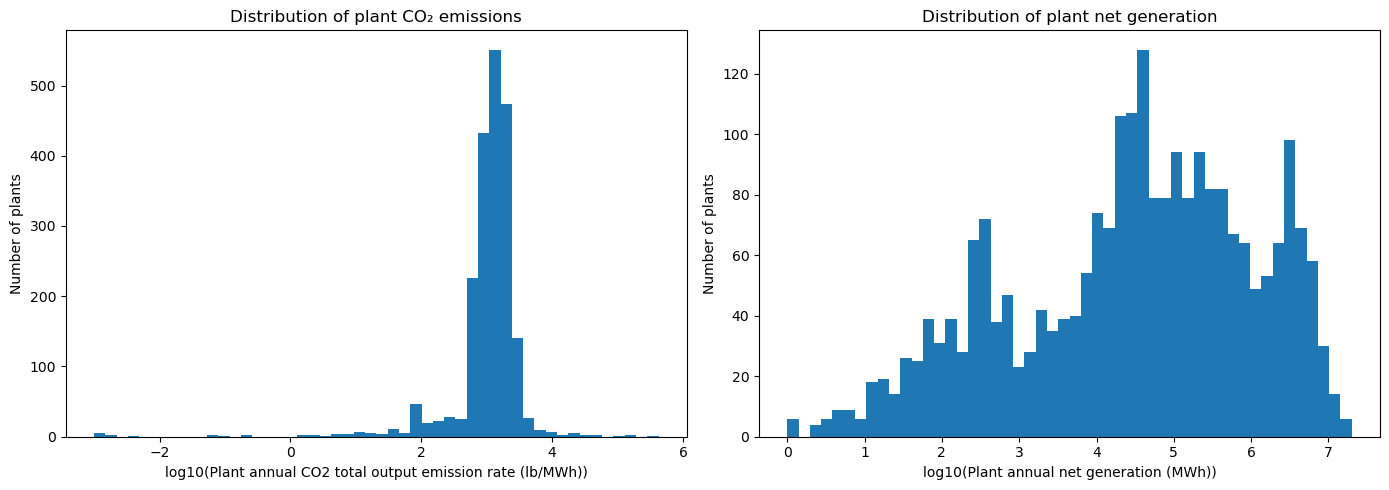

In [26]:
# Filter to only positive values and non-zeros
co2 = df1["Plant annual CO2 total output emission rate (lb/MWh)"]
co2_pos = co2[(co2.notna()) & (co2 > 0)]

gen = df1["Plant annual net generation (MWh)"]
gen_pos = gen[(gen.notna()) & (gen > 0)]

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CO2 histogram (log10)
axes[0].hist(np.log10(co2_pos), bins=50)
axes[0].set_xlabel("log10(Plant annual CO2 total output emission rate (lb/MWh))")
axes[0].set_ylabel("Number of plants")
axes[0].set_title("Distribution of plant CO₂ emissions")

# Net generation histogram (log10)
axes[1].hist(np.log10(gen_pos), bins=50)
axes[1].set_xlabel("log10(Plant annual net generation (MWh))")
axes[1].set_ylabel("Number of plants")
axes[1].set_title("Distribution of plant net generation")

plt.tight_layout()
plt.show()


Distribution of CO2 emissions:

- The span of emissions is from 10^0 to 10^7 tons per year. This shows a large heterogeneity in plant size and fuel output.

- On the log scale the distribution is unimodal with very large right tail, showing that most plant emit between 10^3 to 10^6 tons annually with small number of high emitting plants.

- The log transformation makes the distribution more symmetrical and reduces the influence of extreme emitters.

- These patterns shows that treating all plants as identical would be inappropriate.

Distribution of Plant annual net generation:

- The span of net generation shows large heterogeneity.

- The shape is similar to the CO2 emission graph which is roughly unimodal with longer upper tail, where most plants are between 10^3 to 10^6 tons for energy generation.

- Since both CO2 and generation are heavy tailed on the original scale and unimodal on the log scale it is reasonable to expect an approximately linear relationship between log(CO2) and log(generation), once we control for fuel mix.

Takeaways for Research Question:

For GLM, predicting plant CO2 emission from generation and fuel mix:

- The range in plant size and approximately log normal shape of both variable suggest modeling on a log scale rather than raw tons or MWh.

- A GLM where the response is log(CO2) or emission rate is likely to be more stable and interpretable, and the coefficients can be read as multiplicative effects on emissions.

For a Bayesian hierarchical model with NERC regions:

- Since the plant emissions and generation vary widely, there is room for region level structure. Some NERC regions may have many large, high emitting plants (e.g. Texas). While others are dominated by smaller or cleaner plants.

- Working in log scale will be helpful since it dampens the effect of few extreme plants in each region and make the region level random effects easier to estimate.

In [37]:
%pip install -U arviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 15.7 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 24.0
    Uninstalling packaging-24.0:
      Successfully uninstalled packaging-24.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [arviz]32m3/4 [arviz]]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytest-notebook 0.10.0 requires attrs<23,>=19, but you have attrs 23.2.0 which is incompatible.
myst-parser 0.18.1 requires mdit-py-plugins~=0.3.1, but you have mdit-py-plugins 0.4.2 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [39]:
%pip install -U pymc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.7/536.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [pymc]2m 9/10 [pymc]sor]
Note: you may need to restart the kernel to use updated packages.


In [40]:
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import pymc as pm

## Research Question (Bayesian Hierarchical Model)

After controlling for primary fuel type (eg. coal, gas, nuclear, and renewables), as well as net energy generation, how much residual variation in power plant CO, emission rates can be attributed to other differences between NERC regions?

## Data

In [41]:
plantdf = pd.read_csv('plantdata.csv')

/tmp/ipykernel_115/2279155834.py:1: DtypeWarning: Columns (0,1,4,6,8,16,17,19,20,22,23,27,29,33,34,35,50,51,52,53,55,56,58,59,60,61,62,63,64,65,66,67,68,69,71,72,74,82,85,86,97,98,99,102,107,122) have mixed types. Specify dtype option on import or set low_memory=False.
  plantdf = pd.read_csv('plantdata.csv')


In [42]:
columns_to_keep = [
    # ID
    "Plant file sequence number",

    # Outcome (CO2 intensity)
    "Plant annual CO2 total output emission rate (lb/MWh)",

    # Total CO2 mass
    "Plant annual CO2 emissions (tons)",
    
    # Fuel mix (percentages)
    "Plant coal generation percent (resource mix)",
    "Plant gas generation percent (resource mix)",
    "Plant nuclear generation percent (resource mix)",
    "Plant hydro generation percent (resource mix)",
    "Plant biomass generation percent (resource mix)",
    "Plant wind generation percent (resource mix)",
    "Plant solar generation percent (resource mix)",
    "Plant geothermal generation percent (resource mix)",

    # Primary fuel info (for categorical EDA)
    "Plant primary fuel",
    "Plant primary fuel category",

    # Controls / scale               
    "Plant annual net generation (MWh)",
    "Plant nameplate capacity (MW)",

    # Location / region
    "Plant state abbreviation",
    "NERC region acronym",
    "eGRID subregion acronym"
]


df = plantdf[columns_to_keep]

In [43]:
num_cols = [
    "Plant annual CO2 total output emission rate (lb/MWh)",
    "Plant annual CO2 emissions (tons)",
    "Plant annual net generation (MWh)",
    "Plant nameplate capacity (MW)"
]

df = df.copy()

df.loc[:, num_cols] = df.loc[:, num_cols].astype(str)

df.loc[:, num_cols] = df.loc[:, num_cols].replace({
    ",": "",           
    r"\(": "-",        
    r"\)": "",         
    r"[^\d\.-]": ""     
}, regex=True)

df.loc[:, num_cols] = df.loc[:, num_cols].apply(pd.to_numeric, errors="coerce")

percent_cols = [
    "Plant coal generation percent (resource mix)",
    "Plant gas generation percent (resource mix)",
    "Plant nuclear generation percent (resource mix)",
    "Plant hydro generation percent (resource mix)",
    "Plant biomass generation percent (resource mix)",
    "Plant wind generation percent (resource mix)",
    "Plant solar generation percent (resource mix)",
    "Plant geothermal generation percent (resource mix)"
]

# Clean and convert
df.loc[:, percent_cols] = (
    df.loc[:, percent_cols]
        .astype(str)
        .apply(lambda col: col.str.replace("%", "", regex=False))  # apply .str to each column
        .replace(["--", "", "nan"], np.nan)
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0.0)
)

In [44]:
df = df[df["Plant annual net generation (MWh)"] > 0]
df = df.dropna(subset=["Plant annual CO2 total output emission rate (lb/MWh)"])

In [45]:
print(df.shape)

(3274, 18)


## Feature Engineering

In [46]:
rate_col = "Plant annual CO2 total output emission rate (lb/MWh)"
region_col = "NERC region acronym"
netgen_col = "Plant annual net generation (MWh)"

fuel_percent_cols = [
    "Plant coal generation percent (resource mix)",
    "Plant gas generation percent (resource mix)",
    "Plant nuclear generation percent (resource mix)",
    "Plant hydro generation percent (resource mix)",
    "Plant biomass generation percent (resource mix)",
    "Plant wind generation percent (resource mix)",
    "Plant solar generation percent (resource mix)",
    "Plant geothermal generation percent (resource mix)",
]

# Build dataframe
model_df = df[[rate_col, region_col, netgen_col] + fuel_percent_cols].copy()

# Clean CO2 rate
model_df[rate_col] = (
    model_df[rate_col]
    .astype(str)
    .str.replace(r"[^\d\.\-]", "", regex=True)
    .replace("", np.nan)
)
model_df[rate_col] = pd.to_numeric(model_df[rate_col], errors="coerce")
model_df = model_df[model_df[rate_col] > 0].dropna(subset=[rate_col])

# Clean fuel shares
for c in fuel_percent_cols:
    model_df[c] = pd.to_numeric(model_df[c], errors="coerce").fillna(0.0) / 100.0

renew_cols = [
    "Plant hydro generation percent (resource mix)",
    "Plant biomass generation percent (resource mix)",
    "Plant wind generation percent (resource mix)",
    "Plant solar generation percent (resource mix)",
    "Plant geothermal generation percent (resource mix)",
]

# Derived features
model_df["coal_share"]    = model_df["Plant coal generation percent (resource mix)"]
model_df["gas_share"]     = model_df["Plant gas generation percent (resource mix)"]
model_df["nuclear_share"] = model_df["Plant nuclear generation percent (resource mix)"]
model_df["renew_share"]   = model_df[renew_cols].sum(axis=1)

# clean + log-transform net generation
model_df[netgen_col] = pd.to_numeric(model_df[netgen_col], errors="coerce")
model_df = model_df.dropna(subset=[netgen_col])

# log-transform to avoid huge scale differences
model_df["log_netgen"] = np.log(model_df[netgen_col])

# Target variable
y = np.log(model_df[rate_col].astype("float64").to_numpy())

# Predictors
X_cols = ["coal_share", "gas_share", "nuclear_share", "renew_share", "log_netgen"]
X = model_df[X_cols].astype("float64")

# Standardize
X_std = (X - X.mean()) / X.std()

coal_std = X_std["coal_share"].to_numpy(dtype="float64")
gas_std  = X_std["gas_share"].to_numpy(dtype="float64")
nuc_std  = X_std["nuclear_share"].to_numpy(dtype="float64")
ren_std  = X_std["renew_share"].to_numpy(dtype="float64")
netgen_std = X_std["log_netgen"].to_numpy(dtype="float64")

# Region indexing
regions = model_df[region_col].astype("category")
region_idx = regions.cat.codes.to_numpy(dtype="int32")
n_regions = regions.cat.categories.size

print("y dtype:", y.dtype)
print("coal_std dtype:", coal_std.dtype)
print("netgen_std dtype:", netgen_std.dtype)
print("region_idx dtype:", region_idx.dtype)
print("n_regions:", n_regions)

y dtype: float64
coal_std dtype: float64
netgen_std dtype: float64
region_idx dtype: int32
n_regions: 9


In [47]:
X_std.std()


coal_share       1.0
gas_share        1.0
nuclear_share    1.0
renew_share      1.0
log_netgen       1.0
dtype: float64

## Model

Note:  mu_o and sigma_o from our methods section in the report are represented here by mu_alpha and sigma_alpha

In [48]:
with pm.Model() as bayes_model:

    ##### Regional intercept hyperpriors

    mu_alpha = pm.Normal("mu_alpha", mu=0.0, sigma=5.0)
    sigma_alpha = pm.HalfNormal("sigma_alpha", sigma=1.0)

    ##### Region level intercepts
    
    #non centered parameterization
    z = pm.Normal("z", 0, 1, shape=n_regions)
    alpha = pm.Deterministic("alpha", mu_alpha + z * sigma_alpha)

    ##### Instance-level regression coefficients β

    # 1) Fuel Types (beta_f) 
    fuel_mat = np.column_stack([coal_std, gas_std, nuc_std, ren_std])
    beta_f = pm.Normal("beta_f", 0, 1, shape=4)


    # 2) Net generation effect (beta_g)
    beta_netgen = pm.Normal("beta_netgen", mu=0.0, sigma=1.0)

    ##### Residual noise
    sigma = pm.HalfNormal("sigma", sigma=1.0)

    ##### Predictor 
    mu = alpha[region_idx] + fuel_mat @ beta_f + beta_netgen * netgen_std

    ##### Likelihood
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    ##### Sampling
    idata = pm.sample(
        2000,
        tune=2000,
        target_accept=0.99,
        random_seed=42
    )


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, sigma_alpha, z, beta_f, beta_netgen, sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 41 seconds.


## Posterior Predictive Check

In [49]:
with bayes_model:
    ppc = pm.sample_posterior_predictive(
        idata,
        var_names=["y_obs"],
        random_seed=42
    )
idata.extend(ppc)

Sampling: [y_obs]


Output()

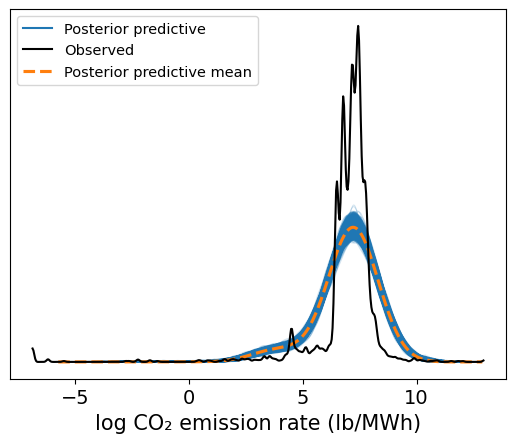

In [50]:
az.plot_ppc(
    idata,
    data_pairs={"y_obs": "y_obs"}
)
plt.xlabel("log CO₂ emission rate (lb/MWh)")
plt.show()


 The posterior predictive check shows the model captured the central mass of the observed distribution well, though it smooths extreme tails indicating a reasonable but not perfect fit.


## Regional Difference Analysis

In [51]:
print(az.summary(idata, var_names=["mu_alpha", "sigma_alpha", "beta_netgen", "sigma"]))
print(az.summary(idata, var_names=["beta_f"]))

              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mu_alpha     6.913  0.033   6.850    6.973      0.001    0.001    3136.0   
sigma_alpha  0.055  0.044   0.000    0.129      0.001    0.001    1651.0   
beta_netgen -0.092  0.026  -0.139   -0.043      0.000    0.000    4216.0   
sigma        1.001  0.013   0.976    1.026      0.000    0.000    9361.0   

             ess_tail  r_hat  
mu_alpha       2892.0    1.0  
sigma_alpha    2542.0    1.0  
beta_netgen    5393.0    1.0  
sigma          6509.0    1.0  
            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta_f[0]  0.064  0.025   0.018    0.111        0.0      0.0    4479.0   
beta_f[1] -0.254  0.029  -0.308   -0.198        0.0      0.0    3796.0   
beta_f[2] -0.241  0.019  -0.277   -0.205        0.0      0.0    9192.0   
beta_f[3] -1.033  0.023  -1.076   -0.989        0.0      0.0    4952.0   

           ess_tail  r_hat  
beta_f[0]    5502.0    1.0  
beta_f[1]    5127.0    1.0  
beta_f

In [52]:
# Extract alpha summary
alpha_summary = az.summary(idata, var_names=["alpha"], kind="stats")

# Get region labels
regions = model_df[region_col].astype("category")
region_labels = regions.cat.categories.values

alpha_summary["region"] = region_labels

print("alpha_j")
display(alpha_summary)


alpha_j


,mean,sd,hdi_3%,hdi_97%,region
alpha[0],6.870,0.066,6.739,6.975,AK
alpha[1],6.923,0.069,6.786,7.058,HI
alpha[2],6.915,0.035,6.846,6.980,MRO
alpha[3],6.958,0.052,6.874,7.062,NPCC
alpha[4],6.908,0.069,6.768,7.046,PR
alpha[5],6.912,0.032,6.848,6.973,RFC
alpha[6],6.892,0.035,6.825,6.955,SERC
alpha[7],6.943,0.046,6.867,7.038,TRE
alpha[8],6.898,0.035,6.829,6.963,WECC


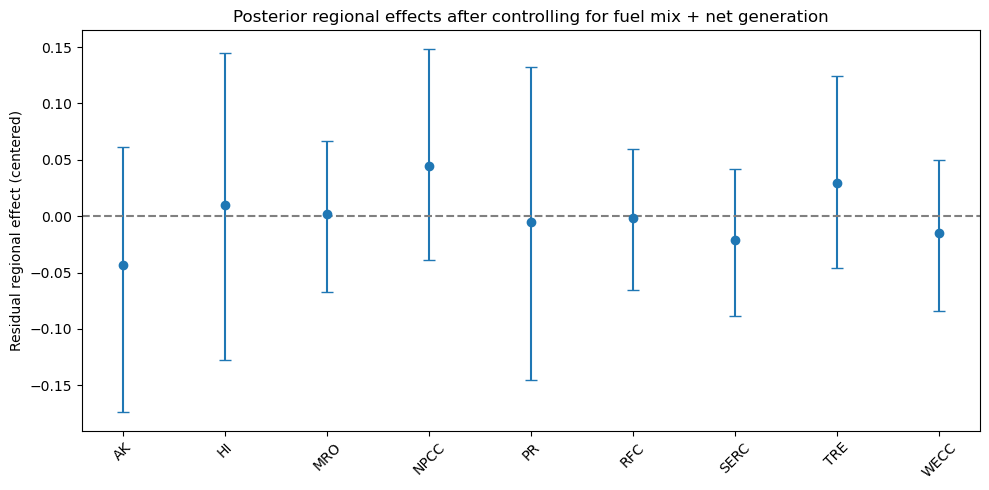

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# Extract posterior means for alpha_j
alpha_mean = alpha_summary["mean"].values   # vector of length n_regions

# Center by subtracting the average regional effect
center_shift = alpha_mean.mean()
alpha_resid = alpha_mean - center_shift

# Shift HDIs the same way
hdi_low  = alpha_summary["hdi_3%"].values  - center_shift
hdi_high = alpha_summary["hdi_97%"].values - center_shift

# Compute error bars (for matplotlib)
lower_err = alpha_resid - hdi_low
upper_err = hdi_high - alpha_resid

# Region labels
region_labels = alpha_summary["region"].values

# Plot
plt.figure(figsize=(10, 5))
plt.errorbar(
    x=region_labels,
    y=alpha_resid,
    yerr=[lower_err, upper_err],
    fmt="o",
    capsize=4,
)
plt.axhline(0, color="gray", linestyle="--")
plt.xticks(rotation=45)
plt.ylabel("Residual regional effect (centered)")
plt.title("Posterior regional effects after controlling for fuel mix + net generation")
plt.tight_layout()
plt.show()


After adjusting for fuel mix and net generation, regional effects were small: all regions differed by less than ~0.1 log-units (~9% on the original scale), and credible intervals overlapped heavily, indicating that most variation in CO₂ emission rates is attributable to plant-level factors rather than region-level characteristics.

## Sensitivity Testing

Changing the prior on sigma_alpha (sigma_o from our methods)

In [54]:
with pm.Model() as tight_model:

    mu_alpha = pm.Normal("mu_alpha", mu=0.0, sigma=5.0)
    sigma_alpha = pm.HalfNormal("sigma_alpha", sigma=2.0)
    ##### region level intercepts
    z = pm.Normal("z", 0, 1, shape=n_regions)
    alpha = pm.Deterministic("alpha", mu_alpha + z * sigma_alpha)
    ##### Instance-level regression coefficients β
    # 1) Fuel Types (beta_f)
    fuel_mat = np.column_stack([coal_std, gas_std, nuc_std, ren_std])
    beta_f = pm.Normal("beta_f", 0, 1, shape=4)
    # 2) Net generation effect (beta_g)
    beta_netgen = pm.Normal("beta_netgen", mu=0.0, sigma=1.0)
    ##### Residual noise
    sigma = pm.HalfNormal("sigma", sigma=1.0)
    ##### Predictor 
    mu = alpha[region_idx] + fuel_mat @ beta_f + beta_netgen * netgen_std
    ##### Likelihood
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)
    ##### Sampling
    idata_tight = pm.sample(
        2000,
        tune=2000,
        target_accept=0.99,
        random_seed=42
    )


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, sigma_alpha, z, beta_f, beta_netgen, sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 45 seconds.


In [55]:
with pm.Model() as loose_model:

    mu_alpha = pm.Normal("mu_alpha", mu=0.0, sigma=5.0)
    sigma_alpha = pm.HalfNormal("sigma_alpha", sigma=0.5)
    ##### region level intercepts
    z = pm.Normal("z", 0, 1, shape=n_regions)
    alpha = pm.Deterministic("alpha", mu_alpha + z * sigma_alpha)
    ##### Instance-level regression coefficients β
    # 1) Fuel Types (beta_f)
    fuel_mat = np.column_stack([coal_std, gas_std, nuc_std, ren_std])
    beta_f = pm.Normal("beta_f", 0, 1, shape=4)
    # 2) Net generation effect (beta_g)
    beta_netgen = pm.Normal("beta_netgen", mu=0.0, sigma=1.0)
    ##### Residual noise
    sigma = pm.HalfNormal("sigma", sigma=1.0)
    ##### Predictor 
    mu = alpha[region_idx] + fuel_mat @ beta_f + beta_netgen * netgen_std
    ##### Likelihood
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)
    ##### Sampling
    idata_loose = pm.sample(
        2000,
        tune=2000,
        target_accept=0.99,
        random_seed=42
    )


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, sigma_alpha, z, beta_f, beta_netgen, sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 33 seconds.
There were 2 divergences after tuning. Increase `target_accept` or reparameterize.


In [56]:
param_labels = ["beta_coal", "beta_gas", "beta_nuclear", "beta_renew"]

def extract_betas(idata):
    bf = az.summary(idata, var_names=["beta_f"])[["mean","sd","hdi_3%","hdi_97%"]]
    bf.index = param_labels
    bnet = az.summary(idata, var_names=["beta_netgen"])[["mean","sd","hdi_3%","hdi_97%"]]
    bnet.index = ["beta_netgen"]
    return pd.concat([bf, bnet], axis=0)

base   = extract_betas(idata);       base["model"] = "baseline"
tight  = extract_betas(idata_tight); tight["model"] = "tight priors"
loose  = extract_betas(idata_loose); loose["model"] = "loose priors"

comparison = pd.concat([base, tight, loose]).reset_index()
comparison = comparison.rename(columns={"index":"parameter"})
comparison = comparison[["model","parameter","mean","sd","hdi_3%","hdi_97%"]]

comparison

,model,parameter,mean,sd,hdi_3%,hdi_97%
0,baseline,beta_coal,0.064,0.025,0.018,0.111
1,baseline,beta_gas,-0.254,0.029,-0.308,-0.198
2,baseline,beta_nuclear,-0.241,0.019,-0.277,-0.205
3,baseline,beta_renew,-1.033,0.023,-1.076,-0.989
4,baseline,beta_netgen,-0.092,0.026,-0.139,-0.043
5,tight priors,beta_coal,0.066,0.025,0.018,0.112
6,tight priors,beta_gas,-0.252,0.029,-0.306,-0.198
7,tight priors,beta_nuclear,-0.241,0.019,-0.275,-0.205
8,tight priors,beta_renew,-1.032,0.023,-1.076,-0.989
9,tight priors,beta_netgen,-0.094,0.026,-0.144,-0.047


Adjusting the prior on the region-level variance did not meaningfully alter the β parameters, consistent with the finding that regional differences are modest after controlling for fuel mix and plant size.

## Research Question (GLM and the Nonparametric Method)

Can we predict CO2 emissions from power plants from NERC grid regions based on nonrenewable and renewable energy generation and other features? 

In [57]:
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.feature_extraction import DictVectorizer

from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

from sklearn import preprocessing

from sklearn.model_selection import KFold
from sklearn.preprocessing import normalize
from sklearn.linear_model import LogisticRegression

from sklearn import tree
from sklearn import ensemble

Import the dataset into plantdf

In [58]:
plantdf = pd.read_csv('plantdata.csv')

/tmp/ipykernel_115/2279155834.py:1: DtypeWarning: Columns (0,1,4,6,8,16,17,19,20,22,23,27,29,33,34,35,50,51,52,53,55,56,58,59,60,61,62,63,64,65,66,67,68,69,71,72,74,82,85,86,97,98,99,102,107,122) have mixed types. Specify dtype option on import or set low_memory=False.
  plantdf = pd.read_csv('plantdata.csv')


In [59]:
plantdf.head()

,Plant file sequence number,Data Year,Plant state abbreviation,Plant name,DOE/EIA ORIS plant or facility code,Plant transmission or distribution system owner name,Plant transmission or distribution system owner ID,Utility name,Utility ID,Plant-level sector,...,Plant geothermal generation percent (resource mix),Plant other fossil generation percent (resource mix),Plant other unknown / purchased fuel generation percent (resource mix),Plant total nonrenewables generation percent (resource mix),Plant total renewables generation percent (resource mix),Plant total nonrenewables other unknown/purchased generation percent (resource mix),Plant total nonhydro renewables generation percent (resource mix),Plant total combustion generation percent (resource mix),Plant total noncombustion generation percent (resource mix),Plant total noncombustion other unknown/purchased generation percent (resource mix)
0,SEQPLT23,YEAR,PSTATABB,PNAME,ORISPL,OPRNAME,OPRCODE,UTLSRVNM,UTLSRVID,SECTOR,...,PLGTPR,PLOFPR,PLOPPR,PLTNPR,PLTRPR,PLTOPR,PLTHPR,PLCYPR,PLCNPR,PLCOPR
1,1,2023,AK,Alakanuk,57053,"Alaska Village Elec Coop, Inc",221,"Alaska Village Elec Coop, Inc",221,Electric Utility,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2023,AK,Allison Creek Hydro,58982,"Copper Valley Elec Assn, Inc",4329,"Copper Valley Elec Assn, Inc",4329,Electric Utility,...,0.0%,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%,0.0%,100.0%,0.0%
3,3,2023,AK,Ambler,60243,"Alaska Village Elec Coop, Inc",221,"Alaska Village Elec Coop, Inc",221,Electric Utility,...,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%
4,4,2023,AK,Angoon,7462,"Inside Passage Elec Coop, Inc",18963,"Inside Passage Elec Coop, Inc",18963,Electric Utility,...,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%


# Data Cleaning 

Select the columns needed for training both GLM and the nonparametric models

In [60]:
columns_to_keep = [
    # ID
    "Plant file sequence number",

    # Outcome (CO2 intensity)
    "Plant annual CO2 total output emission rate (lb/MWh)",
    
    # Fuel mix (percentages)
    "Plant coal generation percent (resource mix)",
    "Plant gas generation percent (resource mix)",
    "Plant nuclear generation percent (resource mix)",
    "Plant hydro generation percent (resource mix)",
    "Plant biomass generation percent (resource mix)",
    "Plant wind generation percent (resource mix)",
    "Plant solar generation percent (resource mix)",
    "Plant geothermal generation percent (resource mix)",
    "CHP plant electric allocation factor",

    # heat information
    "Plant annual heat input from combustion (MMBtu)",
    
    # Primary fuel info (for categorical EDA)
    "Plant primary fuel",
    "Plant primary fuel category",
    "Flag indicating if the plant burned or generated any amount of coal",
    "Combined heat and power (CHP) plant adjustment flag",
    "Plant pumped storage flag",

    # Controls / scale                    
    "Plant annual net generation (MWh)",
    "Plant nameplate capacity (MW)",

    # Location / region
    "Plant state abbreviation",
    "NERC region acronym",
    "eGRID subregion acronym"
]

df = plantdf[columns_to_keep]

In [61]:
df.head(10)

,Plant file sequence number,Plant annual CO2 total output emission rate (lb/MWh),Plant coal generation percent (resource mix),Plant gas generation percent (resource mix),Plant nuclear generation percent (resource mix),Plant hydro generation percent (resource mix),Plant biomass generation percent (resource mix),Plant wind generation percent (resource mix),Plant solar generation percent (resource mix),Plant geothermal generation percent (resource mix),...,Plant primary fuel,Plant primary fuel category,Flag indicating if the plant burned or generated any amount of coal,Combined heat and power (CHP) plant adjustment flag,Plant pumped storage flag,Plant annual net generation (MWh),Plant nameplate capacity (MW),Plant state abbreviation,NERC region acronym,eGRID subregion acronym
0,SEQPLT23,PLCO2RTA,PLCLPR,PLGSPR,PLNCPR,PLHYPR,PLBMPR,PLWIPR,PLSOPR,PLGTPR,...,PLPRMFL,PLFUELCT,COALFLAG,CHPFLAG,PSFLAG,PLNGENAN,NAMEPCAP,PSTATABB,NERC,SUBRGN
1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,DFO,OIL,NaN,Yes,NaN,0,0.8,AK,AK,AKMS
2,2,NaN,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%,0.0%,0.0%,...,WAT,HYDRO,NaN,NaN,NaN,"20,961",6.5,AK,AK,AKMS
3,3,"1,816.360",0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,...,DFO,OIL,NaN,NaN,NaN,"1,239",1.1,AK,AK,AKMS
4,4,"2,105.430",0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,...,DFO,OIL,NaN,NaN,NaN,"1,816",1.5,AK,AK,AKMS
5,5,"2,121.616",0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,...,DFO,OIL,NaN,NaN,NaN,"2,017",1.7,AK,AK,AKMS
6,6,NaN,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%,0.0%,0.0%,...,WAT,HYDRO,NaN,NaN,NaN,"8,383",4.0,AK,AK,AKMS
7,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,DFO,OIL,NaN,NaN,NaN,(236),36.2,AK,AK,AKMS
8,8,"1,922.259",100.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,...,SUB,COAL,Yes,Yes,NaN,"143,360",27.5,AK,AK,AKGD
9,9,"1,937.322",0.0%,100.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,...,NG,GAS,NaN,NaN,NaN,"46,662",17.3,AK,AK,AKMS


In [62]:
df.columns

Index(['Plant file sequence number',
       'Plant annual CO2 total output emission rate (lb/MWh)',
       'Plant coal generation percent (resource mix)',
       'Plant gas generation percent (resource mix)',
       'Plant nuclear generation percent (resource mix)',
       'Plant hydro generation percent (resource mix)',
       'Plant biomass generation percent (resource mix)',
       'Plant wind generation percent (resource mix)',
       'Plant solar generation percent (resource mix)',
       'Plant geothermal generation percent (resource mix)',
       'CHP plant electric allocation factor',
       'Plant annual heat input from combustion (MMBtu)', 'Plant primary fuel',
       'Plant primary fuel category',
       'Flag indicating if the plant burned or generated any amount of coal',
       'Combined heat and power (CHP) plant adjustment flag',
       'Plant pumped storage flag', 'Plant annual net generation (MWh)',
       'Plant nameplate capacity (MW)', 'Plant state abbreviation',
 

In [63]:
df.isna().sum().sort_values(ascending=False)

Plant pumped storage flag                                              12572
Flag indicating if the plant burned or generated any amount of coal    12509
CHP plant electric allocation factor                                   11720
Combined heat and power (CHP) plant adjustment flag                    11682
Plant annual CO2 total output emission rate (lb/MWh)                    9338
Plant annual heat input from combustion (MMBtu)                         8964
Plant solar generation percent (resource mix)                           1066
Plant hydro generation percent (resource mix)                           1066
Plant gas generation percent (resource mix)                             1066
Plant nuclear generation percent (resource mix)                         1066
Plant coal generation percent (resource mix)                            1066
Plant geothermal generation percent (resource mix)                      1066
Plant biomass generation percent (resource mix)                         1066

In [64]:
df.head(20)

,Plant file sequence number,Plant annual CO2 total output emission rate (lb/MWh),Plant coal generation percent (resource mix),Plant gas generation percent (resource mix),Plant nuclear generation percent (resource mix),Plant hydro generation percent (resource mix),Plant biomass generation percent (resource mix),Plant wind generation percent (resource mix),Plant solar generation percent (resource mix),Plant geothermal generation percent (resource mix),...,Plant primary fuel,Plant primary fuel category,Flag indicating if the plant burned or generated any amount of coal,Combined heat and power (CHP) plant adjustment flag,Plant pumped storage flag,Plant annual net generation (MWh),Plant nameplate capacity (MW),Plant state abbreviation,NERC region acronym,eGRID subregion acronym
0,SEQPLT23,PLCO2RTA,PLCLPR,PLGSPR,PLNCPR,PLHYPR,PLBMPR,PLWIPR,PLSOPR,PLGTPR,...,PLPRMFL,PLFUELCT,COALFLAG,CHPFLAG,PSFLAG,PLNGENAN,NAMEPCAP,PSTATABB,NERC,SUBRGN
1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,DFO,OIL,NaN,Yes,NaN,0,0.8,AK,AK,AKMS
2,2,NaN,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%,0.0%,0.0%,...,WAT,HYDRO,NaN,NaN,NaN,"20,961",6.5,AK,AK,AKMS
3,3,"1,816.360",0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,...,DFO,OIL,NaN,NaN,NaN,"1,239",1.1,AK,AK,AKMS
4,4,"2,105.430",0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,...,DFO,OIL,NaN,NaN,NaN,"1,816",1.5,AK,AK,AKMS
5,5,"2,121.616",0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,...,DFO,OIL,NaN,NaN,NaN,"2,017",1.7,AK,AK,AKMS
6,6,NaN,0.0%,0.0%,0.0%,100.0%,0.0%,0.0%,0.0%,0.0%,...,WAT,HYDRO,NaN,NaN,NaN,"8,383",4.0,AK,AK,AKMS
7,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,DFO,OIL,NaN,NaN,NaN,(236),36.2,AK,AK,AKMS
8,8,"1,922.259",100.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,...,SUB,COAL,Yes,Yes,NaN,"143,360",27.5,AK,AK,AKGD
9,9,"1,937.322",0.0%,100.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,...,NG,GAS,NaN,NaN,NaN,"46,662",17.3,AK,AK,AKMS


Transforming the data from object to float for the numerical columns so that we can use Feature Engineering

In [65]:
# transforming the data by changing their data type from object to float
dfc = df.copy()
num_cols = [
    "Plant annual CO2 total output emission rate (lb/MWh)",
    "Plant annual net generation (MWh)",
    "Plant nameplate capacity (MW)",
    "Plant annual heat input from combustion (MMBtu)"
]

percent_cols = [
    "Plant coal generation percent (resource mix)",
    "Plant gas generation percent (resource mix)",
    "Plant nuclear generation percent (resource mix)",
    "Plant hydro generation percent (resource mix)",
    "Plant biomass generation percent (resource mix)",
    "Plant wind generation percent (resource mix)",
    "Plant solar generation percent (resource mix)",
    "Plant geothermal generation percent (resource mix)",
]

def clean_numeric_col(s):
    s = (
        s.astype(str)
         .str.replace(",", "", regex=False)
         .str.replace("(", "-", regex=False)
         .str.replace(")", "", regex=False)
    )
    return pd.to_numeric(s, errors="coerce")

# work on df **in place**
for c in num_cols:
    dfc[c] = clean_numeric_col(df[c])

for c in percent_cols:
    s = (
        df[c].astype(str)
              .str.replace("%", "", regex=False)
              .replace(["--", "", "nan"], np.nan)
    )
    dfc[c] = pd.to_numeric(s, errors="coerce").fillna(0.0)

print(dfc[num_cols + percent_cols].dtypes)

Plant annual CO2 total output emission rate (lb/MWh)    float64
Plant annual net generation (MWh)                       float64
Plant nameplate capacity (MW)                           float64
Plant annual heat input from combustion (MMBtu)         float64
Plant coal generation percent (resource mix)            float64
Plant gas generation percent (resource mix)             float64
Plant nuclear generation percent (resource mix)         float64
Plant hydro generation percent (resource mix)           float64
Plant biomass generation percent (resource mix)         float64
Plant wind generation percent (resource mix)            float64
Plant solar generation percent (resource mix)           float64
Plant geothermal generation percent (resource mix)      float64
dtype: object


In [66]:
dfc.head(10)

,Plant file sequence number,Plant annual CO2 total output emission rate (lb/MWh),Plant coal generation percent (resource mix),Plant gas generation percent (resource mix),Plant nuclear generation percent (resource mix),Plant hydro generation percent (resource mix),Plant biomass generation percent (resource mix),Plant wind generation percent (resource mix),Plant solar generation percent (resource mix),Plant geothermal generation percent (resource mix),...,Plant primary fuel,Plant primary fuel category,Flag indicating if the plant burned or generated any amount of coal,Combined heat and power (CHP) plant adjustment flag,Plant pumped storage flag,Plant annual net generation (MWh),Plant nameplate capacity (MW),Plant state abbreviation,NERC region acronym,eGRID subregion acronym
0,SEQPLT23,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,PLPRMFL,PLFUELCT,COALFLAG,CHPFLAG,PSFLAG,NaN,NaN,PSTATABB,NERC,SUBRGN
1,1,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,DFO,OIL,NaN,Yes,NaN,0.0,0.8,AK,AK,AKMS
2,2,NaN,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,...,WAT,HYDRO,NaN,NaN,NaN,20961.0,6.5,AK,AK,AKMS
3,3,1816.360,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,DFO,OIL,NaN,NaN,NaN,1239.0,1.1,AK,AK,AKMS
4,4,2105.430,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,DFO,OIL,NaN,NaN,NaN,1816.0,1.5,AK,AK,AKMS
5,5,2121.616,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,DFO,OIL,NaN,NaN,NaN,2017.0,1.7,AK,AK,AKMS
6,6,NaN,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,...,WAT,HYDRO,NaN,NaN,NaN,8383.0,4.0,AK,AK,AKMS
7,7,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,DFO,OIL,NaN,NaN,NaN,-236.0,36.2,AK,AK,AKMS
8,8,1922.259,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,SUB,COAL,Yes,Yes,NaN,143360.0,27.5,AK,AK,AKGD
9,9,1937.322,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NG,GAS,NaN,NaN,NaN,46662.0,17.3,AK,AK,AKMS


In [67]:
print(dfc.shape)

(12613, 22)


Categorize the columns by splitting them into categorical columns and numerical columns for Feature Engineering

In [68]:
new_df = dfc[columns_to_keep]
# target column
target_col = "Plant annual CO2 total output emission rate (lb/MWh)"

# features
categorical_cols = [
    "Plant primary fuel",
    "Plant primary fuel category",
    "Plant state abbreviation",
    "NERC region acronym",
    "Flag indicating if the plant burned or generated any amount of coal",
    "Combined heat and power (CHP) plant adjustment flag",
]

numerical_cols = [
    # Fuel mix (percentages)
    "Plant coal generation percent (resource mix)",
    "Plant gas generation percent (resource mix)",
    "Plant nuclear generation percent (resource mix)",
    "Plant hydro generation percent (resource mix)",
    "Plant biomass generation percent (resource mix)",
    "Plant wind generation percent (resource mix)",
    "Plant solar generation percent (resource mix)",
    "Plant geothermal generation percent (resource mix)",
    "CHP plant electric allocation factor",
    # heat
    "Plant annual heat input from combustion (MMBtu)",

    # Controls / scale
    "Plant annual net generation (MWh)",
    "Plant nameplate capacity (MW)"
]

Since we are using the log transformation for the target variables of "Plant annual net generation (MWh)" we need to make sure that it is positive, nonzero and do not contain NA values. We combine the categorical columns and the numerical columns. For our target column we log transform it because it makes the distribution more symmetrical and reduces the influence of extreme emitters.

In [69]:
# Drop rows with missing target
model_df = new_df.dropna(subset=[target_col]).copy()
model_df = new_df[new_df[target_col] > 0]

X = model_df[categorical_cols + numerical_cols]
y = np.log(model_df[target_col])

First, we fill the missing values with the median then scale the numerical features to 0 mean and unit variance. For the categorical features missing values are filled with the most common category and each category is converted into a binary indicator column with one hot encoding. 

In [70]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

## GLM Normal model with Identity Link

Preprocess the features and using Tweedie Regressor, power equal 0 means it is a normal model and iteration max let the optimizer take 2000 iterations to converge. 

In [72]:
# GLM
from sklearn.linear_model import TweedieRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
# from sklearn.linear_model import LinearRegression
# from sklearn.linear_model import GammaRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

glm = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", TweedieRegressor(
    power=0,
    max_iter=2000
))
])

glm.fit(X_train, y_train)
y_pred = glm.predict(X_test)

# metrics on log scale
rmse_glm = mean_squared_error(y_test, y_pred)
r2_glm = r2_score(y_test, y_pred)
print("RMSE (log):", rmse_glm)
print("R^2 (log):", r2_glm)

RMSE (log): 1.7706711243009179
R^2 (log): 0.3464711323144667


## Random Forest Model

For Random Forest model it uses the same preprocessing pipeline to transform the features. Use 300 estimator for a stable prediction, no limit on tree depth until leaves are pure or small, require at least 5 samples in each leaf node, fix random seed so the result is reproducible. 

In [73]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

rf_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=42
    ))
])

Compute RMSE of prediction while in log scale and compute R^2 on the same scale. It measure how well model predict log emission. Model behave better on log scale because the distribution is less skewed. Also computed RMSE and R^2 in real world unit, the result drop for R^2 because it is skewed again.

In [77]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rf_model.fit(X_train, y_train)

# predictions on log scale
y_pred_log = rf_model.predict(X_test)

rmse_log_rf = mean_squared_error(y_test, y_pred_log)
r2_log_rf = r2_score(y_test, y_pred_log)
print("RF RMSE (log scale):", rmse_log_rf)
print("RF R^2 (log scale):", r2_log_rf)

# back to original for interpretation
y_test_orig = np.exp(y_test)
y_pred_orig = np.exp(y_pred_log)

rmse_orig = mean_squared_error(y_test_orig, y_pred_orig)
r2_orig = r2_score(y_test_orig, y_pred_orig)
print("RF RMSE (normal):", rmse_orig)
print("RF R^2 (normal):", r2_orig)


RF RMSE (log scale): 0.2710874990094933
RF R^2 (log scale): 0.8999455608441553
RF RMSE (normal): 311432337.9783411
RF R^2 (normal): 0.03612585147755942


Use 5 fold cross validation to see how well the model generalize to new, unseen data.

In [78]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf_model, X, y,
    cv=5,
    scoring="r2"
)
print("CV R^2 (log scale):", scores.mean(), "+/-", scores.std())

CV R^2 (log scale): 0.8402664484557365 +/- 0.05781880075243948


Find the 20 most important features that help the model make decision in Random Forest.

In [79]:
rf = rf_model.named_steps["model"]
pre = rf_model.named_steps["preprocess"]

# numeric feature names
num_feats = pre.named_transformers_["num"].named_steps["scaler"] \
                 .get_feature_names_out(numerical_cols)

# categorical feature names from one hot encoding
cat_encoder = pre.named_transformers_["cat"].named_steps["onehot"]
cat_feats = cat_encoder.get_feature_names_out(categorical_cols)

all_feature_names = np.concatenate([num_feats, cat_feats])

fi_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": rf.feature_importances_
})

fi_df = fi_df.sort_values("importance", ascending=False)

# top 20 most important features
fi_df["base_feature"] = fi_df["feature"].str.replace(r"^cat__", "", regex=True) \
                                        .str.replace(r"^num__", "", regex=True) \
                                        .str.replace(r"^(.+?)__.*$", r"\1", regex=True)

grouped_fi = fi_df.groupby("base_feature")["importance"].sum().sort_values(ascending=False)
grouped_fi.head(15)

base_feature
Plant biomass generation percent (resource mix)       0.663021
Plant annual heat input from combustion (MMBtu)       0.112403
Plant annual net generation (MWh)                     0.069773
Plant gas generation percent (resource mix)           0.031537
CHP plant electric allocation factor                  0.027661
Plant nameplate capacity (MW)                         0.015046
Plant geothermal generation percent (resource mix)    0.012205
Plant primary fuel_GEO                                0.011510
Plant primary fuel category_GEOTHERMAL                0.011166
Plant hydro generation percent (resource mix)         0.010736
Plant primary fuel_WAT                                0.007021
Plant primary fuel category_HYDRO                     0.005987
Plant coal generation percent (resource mix)          0.005558
Plant solar generation percent (resource mix)         0.003854
Plant primary fuel_WDS                                0.002484
Name: importance, dtype: float64

Use partial dependence plot to see if we vary one feature while keeping everything else the same, how does model output change on average. 

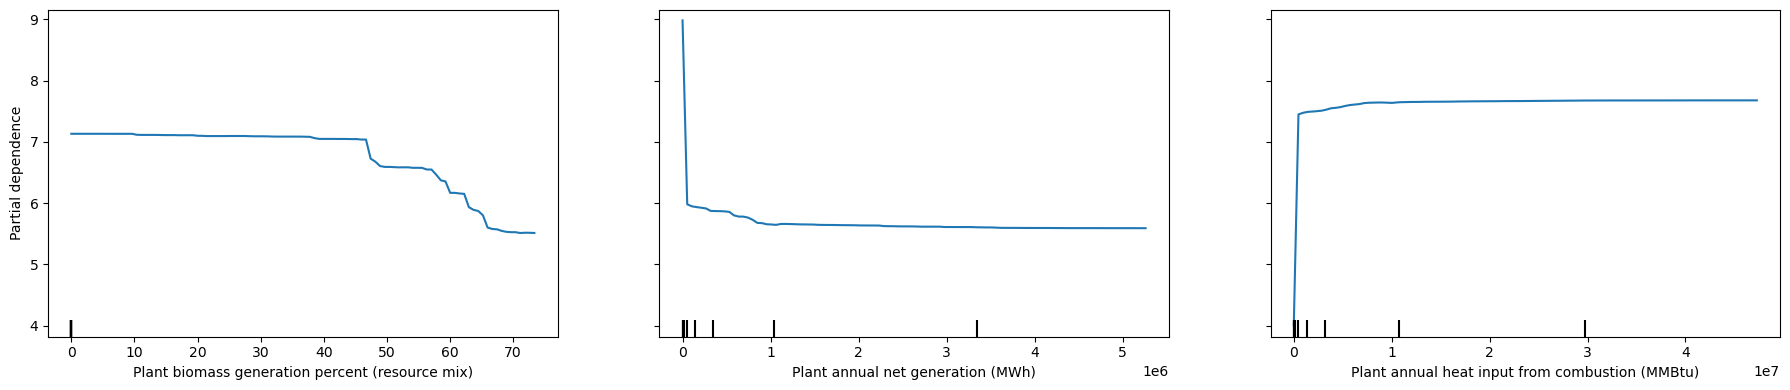

In [80]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

features = [
    "Plant biomass generation percent (resource mix)",
    "Plant annual net generation (MWh)",
    "Plant annual heat input from combustion (MMBtu)",
]

fig, ax = plt.subplots(figsize=(18, 4))
PartialDependenceDisplay.from_estimator(
    rf_model,
    X,
    features=features,
    kind="average",
    ax=ax
)

plt.tight_layout()
plt.show()


Compare GLM and Random Forest on the same table

In [81]:
glm_rmse_log = rmse_glm
glm_r2_log = r2_glm

rf_rmse_log = rmse_log_rf
rf_r2_log = r2_log_rf

cv_r2_mean = scores.mean()
cv_r2_std = scores.std()

results = pd.DataFrame([
    {
        "model": "GLM (linear regression on log CO2)",
        "rmse_log": glm_rmse_log,
        "r2_log": glm_r2_log,
        "notes": "main effects only"
    },
    {
        "model": "Random forest (log CO2)",
        "rmse_log": rf_rmse_log,
        "r2_log": rf_r2_log,
        "cv_r2_log_mean": cv_r2_mean,
        "cv_r2_log_sd": cv_r2_std,
        "notes": "300 trees, min_samples_leaf = 5"
    }
])

results_rounded = results.copy()
for col in ["rmse_log", "r2_log", "cv_r2_log_mean", "cv_r2_log_sd"]:
    results_rounded[col] = results_rounded[col].round(3)
results_rounded

,model,rmse_log,r2_log,notes,cv_r2_log_mean,cv_r2_log_sd
0,GLM (linear regression on log CO2),1.771,0.346,main effects only,NaN,NaN
1,Random forest (log CO2),0.271,0.900,"300 trees, min_samples_leaf = 5",0.84,0.058


Coefficient table for GLM, list the features used in the GLM and their estimated coefficient on the log CO2 emission rate. Sorted from largest positive coefficient to smallest. Can compare the sign and magnitude of these coefficients to understand which characteristic most strongly increase or decrease emission.

In [82]:
glm_model = glm.named_steps["model"]
pre_glm = glm.named_steps["preprocess"]

num_feats = pre_glm.named_transformers_["num"].named_steps["scaler"] \
.get_feature_names_out(numerical_cols)

cat_encoder_glm = pre_glm.named_transformers_["cat"].named_steps["onehot"]
cat_feats = cat_encoder_glm.get_feature_names_out(categorical_cols)

all_feature_names_glm = np.concatenate([num_feats, cat_feats])

coef = glm_model.coef_

coef_df = pd.DataFrame({
    "feature": all_feature_names_glm,
    "coefficient": coef
})

coef_df = coef_df.sort_values("coefficient", ascending=False)

coef_df.head(15)

,feature,coefficient
0,Plant coal generation percent (resource mix),0.086481
52,Plant primary fuel category_OIL,0.082533
17,Plant primary fuel_DFO,0.076886
8,CHP plant electric allocation factor,0.031706
23,Plant primary fuel_MSW,0.029994
110,NERC region acronym_MRO,0.025276
46,Plant primary fuel category_COAL,0.021424
11,Plant nameplate capacity (MW),0.020642
9,Plant annual heat input from combustion (MMBtu),0.013736
115,NERC region acronym_TRE,0.013630


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=d320b00a-c448-4c36-86e1-9e05a8589248' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>